In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from pathlib import Path

In [2]:
###########################################################
# Parameters
###########################################################

N = 2000

N_E = int(0.8 * N)

D = 5

TAU_STAR = 3

MS = 6

FS = 14

DATA_DIR = Path("../sample_snapshot_data")

ONE_DIR = DATA_DIR / "one_cycle"

MULTI_DIR = DATA_DIR / "multi_cycle"

In [4]:
###########################################################
# Load adjacency matrix
###########################################################

network_file = DATA_DIR / "RandomNetwork.txt"

with open(network_file) as f:

    n_nodes, n_links, _ = map(int, f.readline().split())

    adjacency = np.zeros(
        (n_nodes, n_nodes),
        dtype=int
    )

    for _ in range(n_links):

        i, j, w = map(
            int,
            f.readline().split()
        )

        adjacency[i, j] = w

print("Network loaded.")

Network loaded.


In [9]:
###########################################################
# Compute snapshot currents
###########################################################

def compute_currents(
    folder,
    suffix,
    tau_star,
    adjacency,
):
    """
    Compute fresh, residual and total currents
    from one snapshot realization.
    """

    #######################################################
    # Load potential reactivation matrix
    #######################################################

    potential = np.loadtxt(
         folder / f"PotentialReactivation_{suffix}.txt"
    )

    residual_current = potential[
        tau_star + 1,
        1:
    ]

    #######################################################
    # Load active neurons
    #######################################################

    active_nodes_tau = []

    with open(
         folder / f"ActiveNodesInTau_{suffix}.txt"
    ) as f:

        for line in f:

            row = np.fromstring(
                line,
                sep=" ",
                dtype=int
            )

            active_nodes_tau.append(row[1:])

    #######################################################
    # Fresh contribution
    #######################################################

    fresh_nodes = np.asarray(
        active_nodes_tau[tau_star],
        dtype=int
    )

    fresh_current = np.zeros(N)

    for neuron in fresh_nodes:

        fresh_current += adjacency[neuron]

    #######################################################
    # Total current
    #######################################################

    total_current = (
        fresh_current
        + residual_current
    )

    #######################################################
    # Seed neurons
    #######################################################

    seed_count = np.sum(
        total_current > D
    )

    return (
        fresh_current,
        residual_current,
        total_current,
        seed_count,
    )

Text(0.05, 0.8, '$N_{seed}=1$')

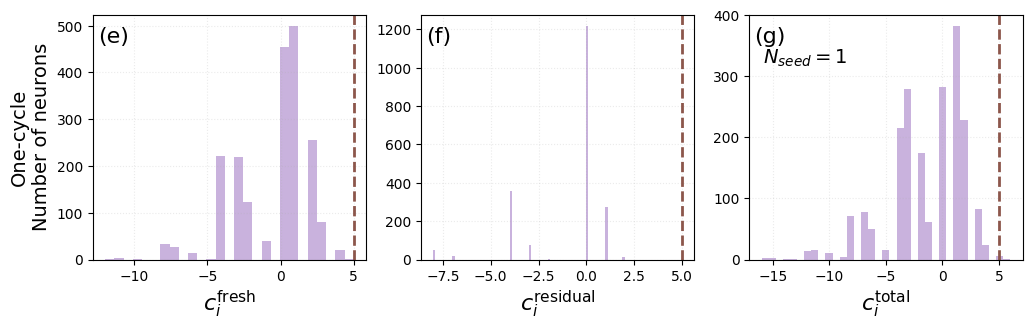

In [22]:
###########################################################
# Create figure
###########################################################

fig = plt.figure(
    figsize=(12, 7),
    facecolor="white"
)

gs = GridSpec(
    2,
    3,
    figure=fig
)


###########################################################
# Panels e, f and g
###########################################################

titles = [
    r"$c_i^{\mathrm{fresh}}$",
    r"$c_i^{\mathrm{residual}}$",
    r"$c_i^{\mathrm{total}}$"
]

datasets = [
    fresh_one,
    residual_one,
    total_one
]

labels = [
    "(e)",
    "(f)",
    "(g)"
]

for i in range(3):

    ax = fig.add_subplot(gs[0, i])

    ax.hist(
        datasets[i],
        bins="auto",
        color="C4",
        alpha=0.5
    )

    ax.axvline(
        D,
        linestyle="--",
        color="C5",
        linewidth=2
    )

    ax.grid(
        linestyle=":",
        alpha=0.25
    )

    ax.set_xlabel(
        titles[i],
        fontsize=FS + 2
    )

    if i == 0:

        ax.set_ylabel(
            "One-cycle\nNumber of neurons",
            fontsize=FS
        )

    ax.text(
        0.02,
        0.95,
        labels[i],
        transform=ax.transAxes,
        fontsize=FS + 2,
        va="top"
    )

ax.text(
    0.05,
    0.80,
    rf"$N_{{seed}}={seed_one}$",
    transform=ax.transAxes,
    fontsize=FS
)

Text(0.05, 0.8, '$N_{seed}=24$')

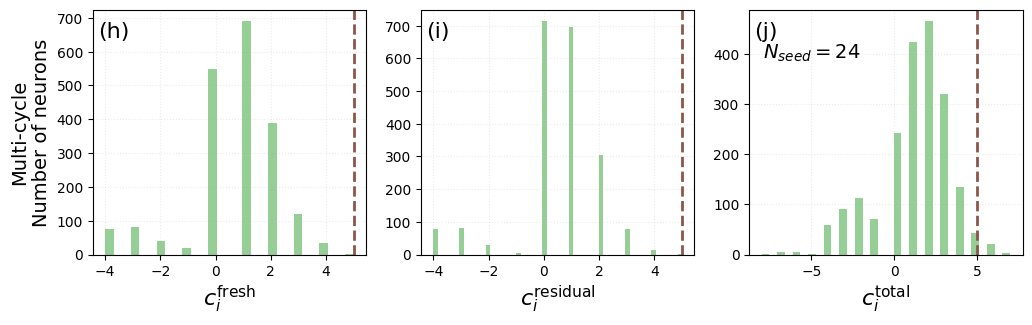

In [21]:
###########################################################
# Create figure
###########################################################

fig = plt.figure(
    figsize=(12, 7),
    facecolor="white"
)

gs = GridSpec(
    2,
    3,
    figure=fig
)


###########################################################
# Panels h, i and j
###########################################################

titles = [
    r"$c_i^{\mathrm{fresh}}$",
    r"$c_i^{\mathrm{residual}}$",
    r"$c_i^{\mathrm{total}}$"
]

datasets = [
    fresh_multi,
    residual_multi,
    total_multi
]

labels = [
    "(h)",
    "(i)",
    "(j)"
]

for i in range(3):

    ax = fig.add_subplot(gs[1, i])

    ax.hist(
        datasets[i],
        bins="auto",
        color="C2",
        alpha=0.5
    )

    ax.axvline(
        D,
        linestyle="--",
        color="C5",
        linewidth=2
    )

    ax.grid(
        linestyle=":",
        alpha=0.25
    )

    ax.set_xlabel(
        titles[i],
        fontsize=FS + 2
    )

    if i == 0:

        ax.set_ylabel(
            "Multi-cycle\nNumber of neurons",
            fontsize=FS
        )

    ax.text(
        0.02,
        0.95,
        labels[i],
        transform=ax.transAxes,
        fontsize=FS + 2,
        va="top"
    )

ax.text(
    0.05,
    0.80,
    rf"$N_{{seed}}={seed_multi}$",
    transform=ax.transAxes,
    fontsize=FS
)